# Burn severity in Rhodes, Greece (2023)

**Note:** This example is based on the _Introduction to Geospatial Raster and Vector Data with Python_ tutorial available [here](https://carpentries-incubator.github.io/geospatial-python/).

## Settings

### Packages

In [26]:
## List packages
pkgs <- c("rstac", "sf", "lubridate", "terra", "dplyr", "tidyterra", "ggplot2")

## Install missing packages
pkgs_installed <- pkgs %in% rownames(installed.packages())
if (any(pkgs_installed == FALSE)) install.packages(pkgs[!pkgs_installed])

## Load packages
invisible(lapply(pkgs, library, character.only = TRUE))


Attaching package: ‘tidyterra’

The following object is masked from ‘package:stats’:

    filter



### Plotting options

In [33]:
options(repr.plot.width  =  12,
        repr.plot.height =   8,
        repr.plot.res    = 150)

theme_set(
  theme_bw() +
  theme(plot.title = element_text(size = 12, face = "bold", hjust = 0.5),
        plot.title.position = "plot",
        strip.text = element_text(size = 10, face = "bold"),
        axis.text = element_text(size = 10),
        axis.title = element_text(size = 10),
        legend.title = element_text(size = 11, face = "bold"),
        legend.text = element_text(size = 11),
        legend.key.width = unit(0.5, "cm"),
        legend.key.height = unit(0.5, "cm"),
        legend.position = "right")
)

### Custom functions

In [3]:
## Convert dates to RFC3339 format
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, limit = 100,
                          start_date, end_date, target_date = NULL,
                          bbox = NULL, roi_path = NULL, thresh_cloud = NULL,
                          asset_names = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start_date, end_date), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange,
                  limit       = limit)
    
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }

    ### (Sub)select and fetch items
    items <- post_request(search)
    if(!is.null(thresh_cloud)) {
        items <- post_request(search)
        suppressWarnings(items <- items_filter(items, properties$`eo:cloud_cover` < thresh_cloud))
    }
    items <- items_fetch(items, progress = FALSE)
    if(!is.null(asset_names)) {
        items <- assets_select(items, asset_names = asset_names)
    }
    if(!is.null(target_date)) {
        target_date <- date2rfc3339(target_date)
        items <- items_select(items, selection = which(items_datetime(items) == as.Date(target_date)))
    }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

### Parameters

In [4]:
## STAC endpoint URL
cons_endpoint <- "https://earth-search.aws.element84.com/v1"

## Dataset collection ID
param_collection <- "sentinel-2-l2a"

## Path to the file defining the region-of-interest
param_roi_path <- "data/rois/wf_rhodes_2023.gpkg"

## Target coordinate reference system code
param_crs_t <- "EPSG:32635"

## Start and end dates
param_date_start <- "2023-07-01"
param_date_end <- "2023-08-31"

## Pre- and post-fire dates
param_date_pre <- "2023-07-08"
param_date_post <- "2023-08-27"

## Cloud cover threshold
param_thresh_cloud <- 30

## Asset codes
param_bands <- c("nir08", "swir22")

## Path to the directory to save outputs
param_dir_out <- tempdir()
if (!dir.exists(param_dir_out)) dir.create(param_dir_out)

## Region of interest

### Import and reproject boundaries

In [5]:
## Rhodes
rhodes <- "data/rois/rhodes.gpkg" |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
rhodes_sv <- project(vect(rhodes), param_crs_t)

## Burned area
roi <- param_roi_path |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
roi_sv <- project(vect(roi), param_crs_t)

### Visualize region of interest

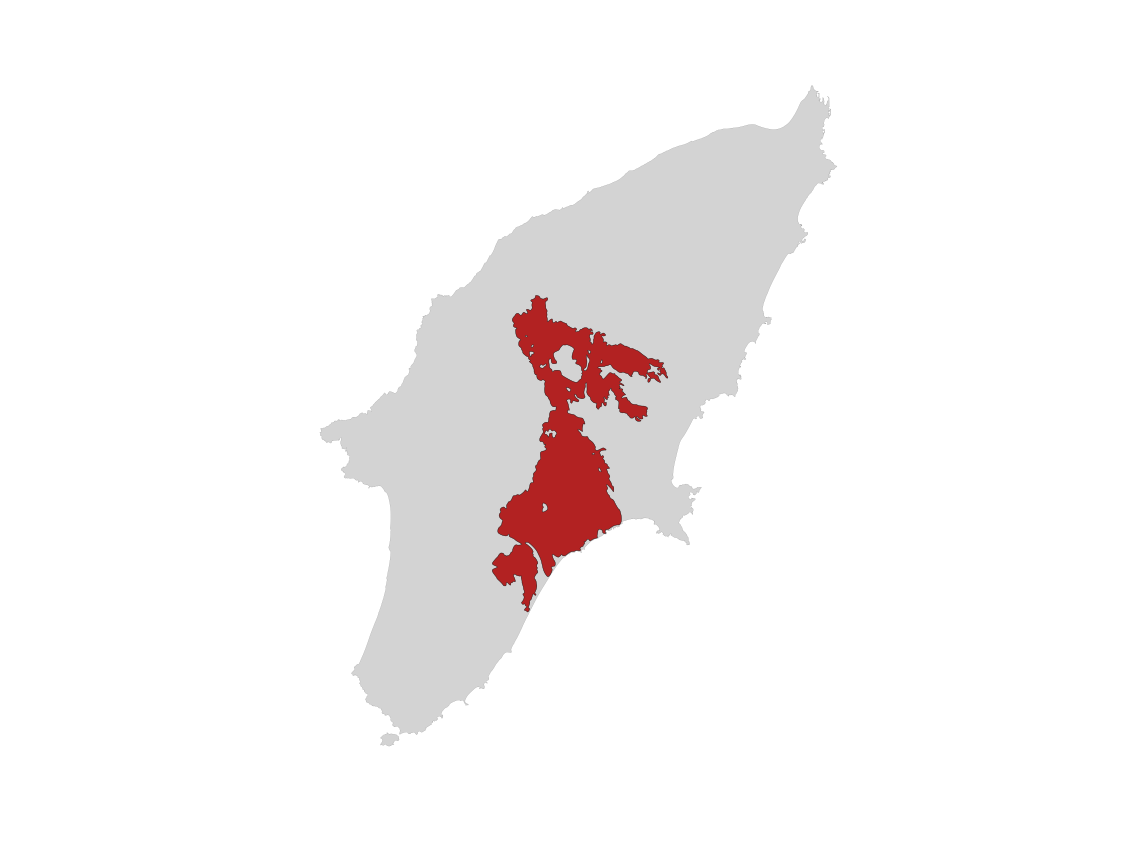

In [6]:
plot(rhodes$geom, col = "lightgray", lwd = 0.1)
plot(roi$geom, col = "firebrick", lwd = 0.5, add = TRUE)

## Data downloading

### Select and download pre-fire images

In [7]:
# STAC Download Prefire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_pre: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_pre: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

dl_files_pre <- stac_download(endpoint     = cons_endpoint,
                              collection   = param_collection,
                              limit        = 100,
                              start        = param_date_start,
                              end          = param_date_end,
                              roi_path     = "data/rois/rhodes.gpkg",
                              asset_names  = param_bands,
                              target_date  = param_date_pre,
                              out_path     = param_dir_out)

In [8]:
# List results
items_as_tibble(dl_files_pre)

# A tibble: 3 × 41
  constellation created                  datetime    earthsearch:boa_offs…¹ earthsearch:payload_…²
  <chr>         <chr>                    <chr>       <lgl>                  <chr>                 
1 sentinel-2    2023-07-08T17:31:07.727Z 2023-07-08… TRUE                   roda-sentinel2/workfl…
2 sentinel-2    2023-07-08T17:39:48.136Z 2023-07-08… TRUE                   roda-sentinel2/workfl…
3 sentinel-2    2023-07-08T17:25:06.447Z 2023-07-08… TRUE                   roda-sentinel2/workfl…
# ℹ abbreviated names: ¹​`earthsearch:boa_offset_applied`, ²​`earthsearch:payload_id`
# ℹ 36 more variables: `earthsearch:s3_path` <chr>, `eo:cloud_cover` <dbl>, `grid:code` <chr>,
#   instruments <chr>, `mgrs:grid_square` <chr>, `mgrs:latitude_band` <chr>,
#   `mgrs:utm_zone` <int>, platform <chr>, `processing:software` <list>, `proj:epsg` <int>,
#   `s2:cloud_shadow_percentage` <dbl>, `s2:dark_features_percentage` <dbl>,
#   `s2:datastrip_id` <chr>, `s2:datatake_id` <chr>, `s2:da

### Select and download pre-fire images

In [9]:
# STAC Download Postfire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_post: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_post: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

dl_files_post <- stac_download(endpoint     = cons_endpoint,
                               collection   = param_collection,
                               limit        = 100,
                               start        = param_date_start,
                               end          = param_date_end,
                               roi_path     = "data/rois/rhodes.gpkg",
                               asset_names  = param_bands,
                               target_date  = param_date_post,
                               out_path     = param_dir_out)

In [10]:
# List results
items_as_tibble(dl_files_post)

# A tibble: 3 × 41
  constellation created                  datetime    earthsearch:boa_offs…¹ earthsearch:payload_…²
  <chr>         <chr>                    <chr>       <lgl>                  <chr>                 
1 sentinel-2    2023-08-27T18:20:46.953Z 2023-08-27… TRUE                   roda-sentinel2/workfl…
2 sentinel-2    2023-08-27T18:15:43.106Z 2023-08-27… TRUE                   roda-sentinel2/workfl…
3 sentinel-2    2023-08-27T18:21:54.510Z 2023-08-27… TRUE                   roda-sentinel2/workfl…
# ℹ abbreviated names: ¹​`earthsearch:boa_offset_applied`, ²​`earthsearch:payload_id`
# ℹ 36 more variables: `earthsearch:s3_path` <chr>, `eo:cloud_cover` <dbl>, `grid:code` <chr>,
#   instruments <chr>, `mgrs:grid_square` <chr>, `mgrs:latitude_band` <chr>,
#   `mgrs:utm_zone` <int>, platform <chr>, `processing:software` <list>, `proj:epsg` <int>,
#   `s2:cloud_shadow_percentage` <dbl>, `s2:dark_features_percentage` <dbl>,
#   `s2:datastrip_id` <chr>, `s2:datatake_id` <chr>, `s2:da

## List downloaded files

### List all downloaded files

In [11]:
dl_files <- list.files(path = param_dir_out,
                       pattern = "*.tif",
                       full.names = TRUE,
                       recursive = TRUE)
print(dl_files)

 [1] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
 [2] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
 [3] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
 [4] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
 [5] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
 [6] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
 [7] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
 [8] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
 [9] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[10] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"
[11] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L

### Build table with all properties

In [12]:
dl_files_sep <- strsplit(dl_files, split = "/")
dl_files_df <- cbind(dl_files, as.data.frame(do.call(rbind, lapply(dl_files_sep, rbind))))
names(dl_files_df) <- c("path", "root", "dir", "subdir", "collection", "zone",
                        "area", "tile", "year", "month", "name", "band")
dl_files_df

                                                                                   path root dir
1  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif      tmp
2  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif      tmp
3  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif      tmp
4  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif      tmp
5  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif      tmp
6  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif      tmp
7  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif      tmp
8  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif      tmp
9  /tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif      tmp
10 /tmp/Rtmpz46d77/sentinel-s2

### Apply grouping to pre-fire images

In [13]:
pre_list <- filter(dl_files_df, month == "7")
print(pre_list$path)

[1] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
[2] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
[3] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
[4] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
[5] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[6] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"


### Apply grouping to post-fire images

In [14]:
post_list <- filter(dl_files_df, month == "8")
print(post_list$path)

[1] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
[2] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
[3] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
[4] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
[5] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B12.tif"
[6] "/tmp/Rtmpz46d77/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B8A.tif"


## Image preprocessing

### Mosaic (merge) different tiles

The three scenes/tiles have to be merged into one image for each of pre- and post-fire:

In [15]:
## Merge tiles for pre-fire images
s2_pre_path <- paste0(param_dir_out, "/s2_pre.tif")
merge(x = rast(filter(pre_list, tile == "NA")$path),
      y = rast(filter(pre_list, tile == "NV")$path),
      z = rast(filter(pre_list, tile == "PA")$path),
      filename = s2_pre_path, overwrite = TRUE)
gc()

          used (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1759927 94.0    2634592 140.8  2634592 140.8
Vcells 3109666 23.8    8388608  64.0  5350281  40.9

In [16]:
## Merge tiles for post-fire images
s2_post_path <- paste0(param_dir_out, "/s2_post.tif")
merge(x = rast(filter(post_list, tile == "NA")$path),
      y = rast(filter(post_list, tile == "NV")$path),
      z = rast(filter(post_list, tile == "PA")$path),
      filename = s2_post_path, overwrite = TRUE)
gc()

          used (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1760278 94.1    2634592 140.8  2634592 140.8
Vcells 3110827 23.8    8388608  64.0  5350281  40.9

### Crop pre-fire image

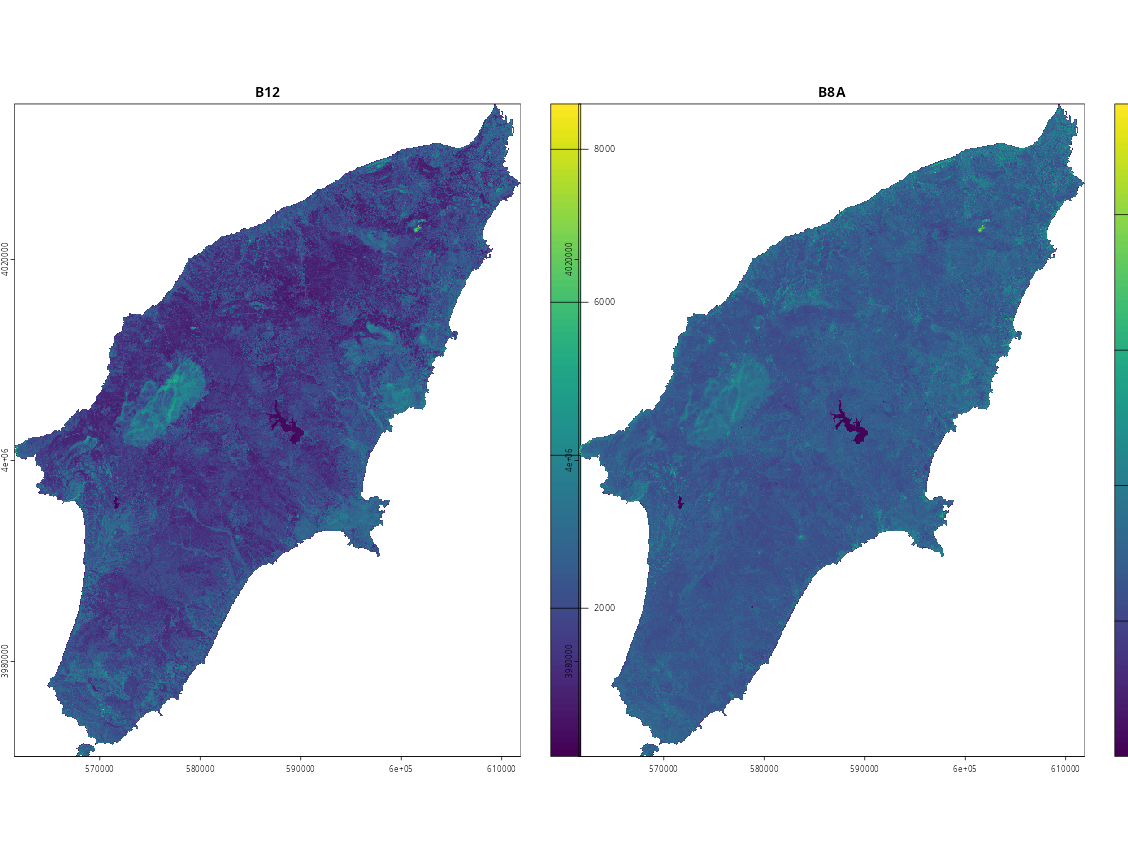

In [17]:
s2_pre_path_c <- paste0(param_dir_out, "/s2_pre_c.tif")
crop(x = rast(s2_pre_path), y = rhodes_sv, mask = TRUE,
     filename = s2_pre_path_c, overwrite = TRUE)
gc()

plot(rast(s2_pre_path_c))

### Crop post-fire image

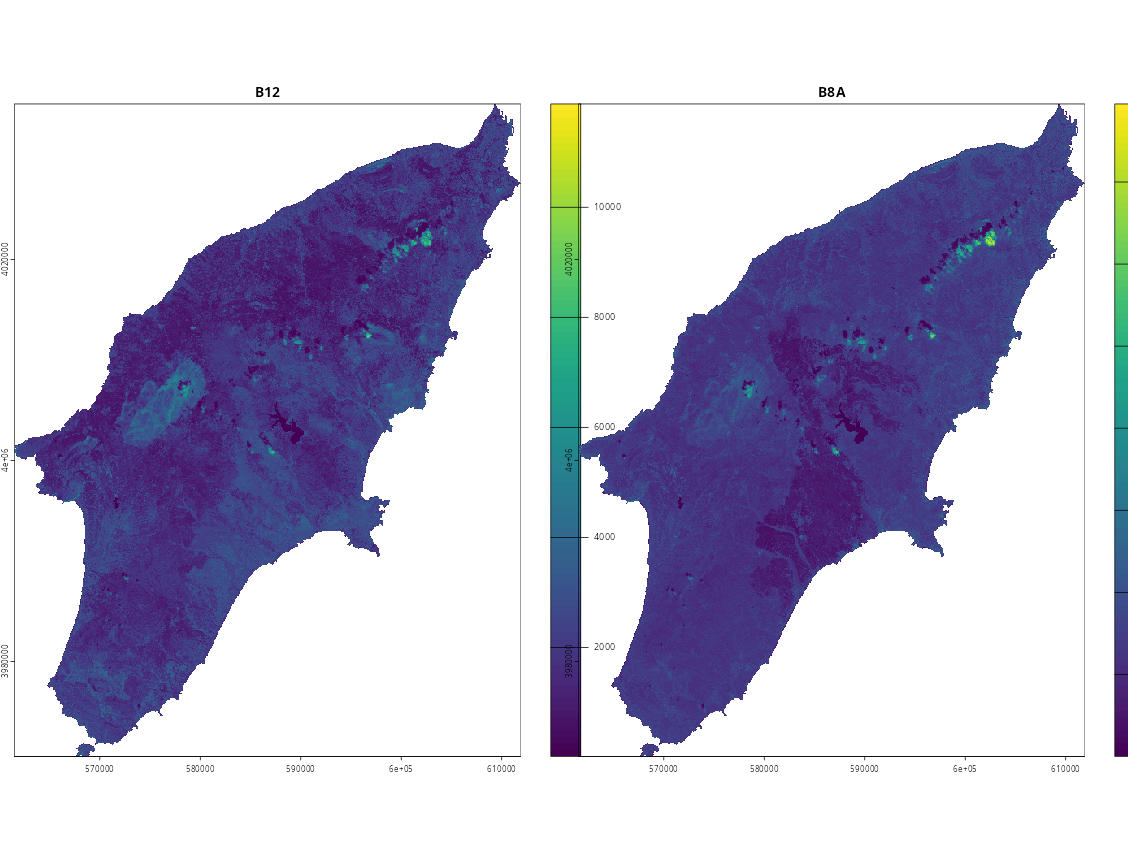

In [18]:
s2_post_path_c <- paste0(param_dir_out, "/s2_post_c.tif")
crop(x = rast(s2_post_path), y = rhodes_sv, mask = TRUE,
     filename = s2_post_path_c, overwrite = TRUE)
gc()

plot(rast(s2_post_path_c))

## Burn severity assessment

The Normalized Burn Ratio (NBR) can be calculated, from the Sentinel-2 bands 8 (near-infrared, NIR) and 12 (shortwave-infrared, SWIR), using the following expression:

$`NBR = {(NIR - SWIR) \over{(NIR + SWIR)}}`$

### Compute pre-fire NBR

In [19]:
s2_pre_path_nbr <- paste0(param_dir_out, "/s2_pre_nbr.tif")
lapp(x = rast(s2_pre_path_c),
     fun = \(B8A, B12) ((B8A - B12) / (B8A + B12)),
     usenames = TRUE, cores = 3,
     filename = s2_pre_path_nbr, overwrite = TRUE)
gc()

           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  1800875  96.2   12316358 657.8 10023943 535.4
Vcells 15442146 117.9   83831479 639.6 87257790 665.8

### Compute post-fire NBR

In [20]:
s2_post_path_nbr <- paste0(param_dir_out, "/s2_post_nbr.tif")
lapp(x = rast(s2_post_path_c),
     fun = \(B8A, B12) ((B8A - B12) / (B8A + B12)),
     usenames = TRUE, cores = 3,
     filename = s2_post_path_nbr, overwrite = TRUE)
gc()

           used  (Mb) gc trigger  (Mb)  max used  (Mb)
Ncells  1801142  96.2    9913583 529.5  10023943 535.4
Vcells 15443891 117.9   80542220 614.5 100677624 768.2

### Visualize NBR maps

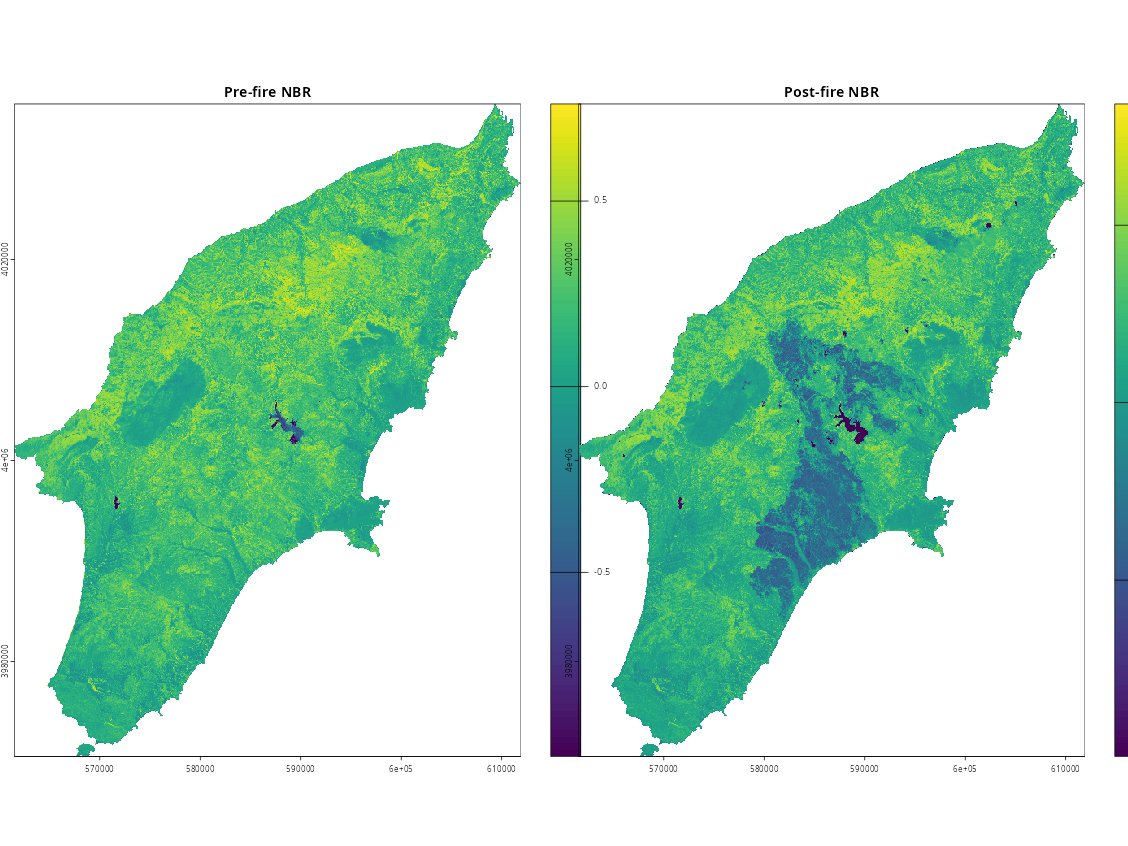

In [21]:
s2_nbr <- c(rast(s2_pre_path_nbr), rast(s2_post_path_nbr))
names(s2_nbr) <- c("Pre-fire NBR", "Post-fire NBR")
plot(s2_nbr)

### Calculate dNBR

Burn severity can be mapped using Delta-NBR, calculated as follows:

$`dNBR = {NBR_{pre} - NBR_{post}}`$

In [22]:
s2_dnbr_path <- paste0(param_dir_out, "/s2_dnbr.tif")
xapp(x = rast(s2_pre_path_nbr), y = rast(s2_post_path_nbr),
     fun = \(x, y) (x - y), filename = s2_dnbr_path, overwrite = TRUE)
gc()

           used  (Mb) gc trigger   (Mb)  max used   (Mb)
Ncells  1803299  96.4   33414580 1784.6  41768225 2230.7
Vcells 16452177 125.6   64433776  491.6 100677624  768.2

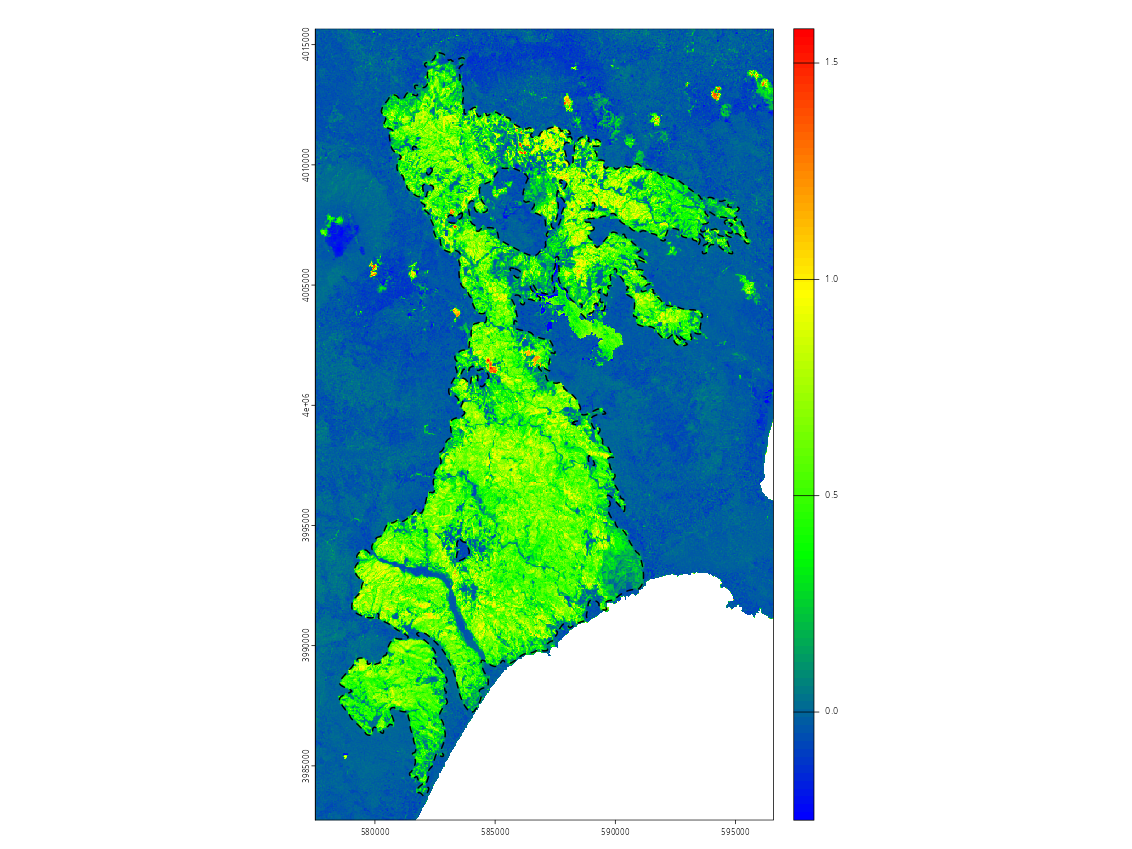

In [34]:
s2_dnbr <- rast(s2_dnbr_path) |>
  crop(buffer(roi_sv, 1000), mask = FALSE)
names(s2_dnbr) <- "dnbr"
s2_dnbr |>
  clamp(lower = -0.25, upper = 2) |>
  plot(col = map.pal("bgyr", n = 100))
plot(roi_sv, lty = 2, lwd = 2, add = TRUE)

## Classify burn severity

Delta Normalized Burn Ratio (dNBR) classes derived from Sentinel-2 imagery quantify wildfire and burn severity by calculating the difference between pre- and post-fire Normalized Burn Ratio (NBR) values.

These categories are mapped according to standard thresholds initially defined by the USGS and Monitoring Trends in Burn Severity (MTBS) programs.

The standard dNBR severity classification ranges are generally divided as follows:

| Burn Severity Class | dNBR Value Range | Description                                                  |
| :------------------ | ---------------: | :----------------------------------------------------------- |
| Enhanced Regrowth   |         < -0.100 | High post-fire vegetation productivity or new growth.        |
| Unburned            | -0.100 to +0.100 | Minimal or no change to vegetation cover.                    |
| Low Severity        | +0.101 to +0.269 | Scorched understory, minimal canopy tree mortality.          |
| Moderate Severity   | +0.270 to +0.439 | Partial canopy scorch, mixed severity.                       |
| High Severity       | +0.440 to +0.659 | Widespread canopy consumption or heavy charring.             |
| Very High Severity  | > 0.659          | Complete consumption of overstory and understory vegetation. |

### Define burn severity classes

In [40]:
severity_classes <- data.frame(name = c("Regrowth", "Unburned", "Low",
                                        "Moderate", "High", "Very high"),
                               description = c("Vegetation regrowth", "Little to no damage",
                                               "Minor vegetation loss or early signs of damage",
                                               "Partial vegetation loss",
                                               "Significant vegetation loss",
                                               "Extensive vegetation loss and exposed soil"),
                               lower = c(-Inf, -0.1, 0.1, 0.27, 0.44, 0.66),
                               upper = c(-0.1, 0.1, 0.27, 0.44, 0.66, Inf),
                               color = c("#0000ff", "#2eb82c", "#f1dd00",
                                         "#fda71d", "#d52903", "#6e01a3"))

### Map burn severity classes

SpatRaster resampled to ncells = 501278


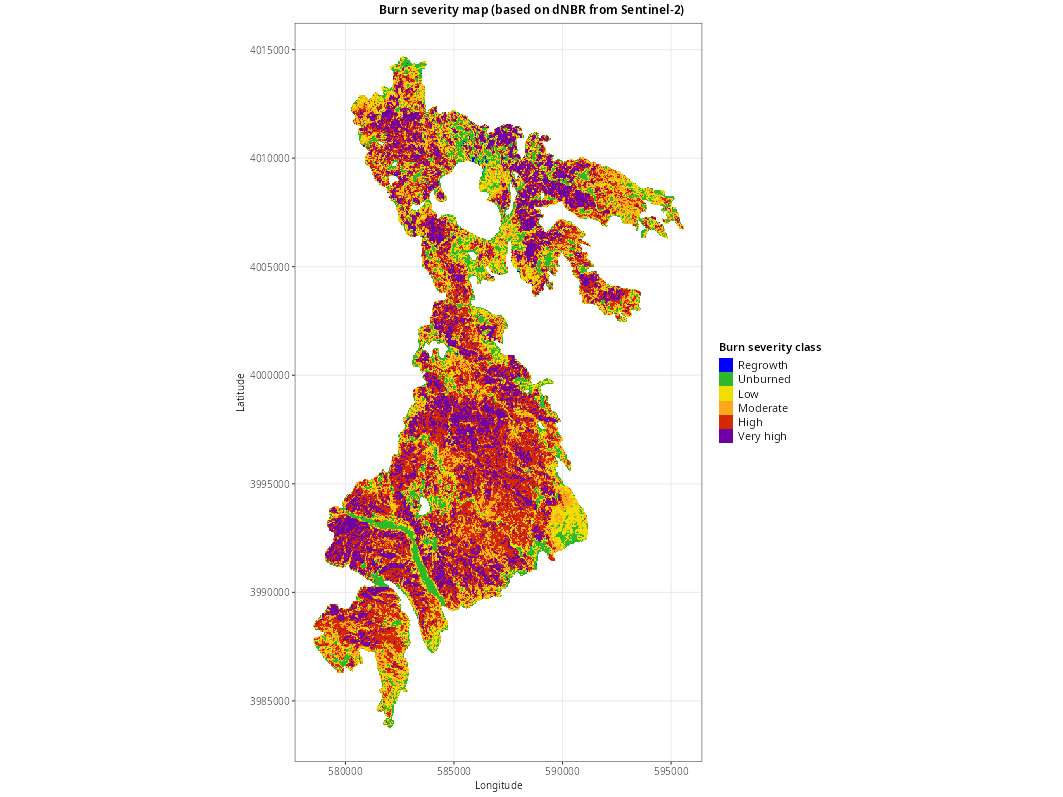

In [41]:
s2_sev <- s2_dnbr |>
  crop(roi_sv, mask = TRUE) |>
  mutate(sev = cut(dnbr, breaks = c(-Inf, severity_classes$upper),
                         labels = severity_classes$name))

ggplot() +
  geom_spatraster(data = s2_sev[["sev"]]) +
  coord_sf(datum = st_crs(32635)) +
  scale_fill_manual(values = severity_classes$color, na.translate = FALSE) +
  #theme(legend.position = "bottom") +
  labs(title = "Burn severity map (based on dNBR from Sentinel-2)",
       x = "Longitude", y = "Latitude", fill = "Burn severity class")